### Import Libraries

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


### Load the Data

In [5]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Misisng Values
- Find Missing Values
- Fill Missing Values


## Find Missing Values

In [7]:
# Calculate missing value counts and percentages
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
print('Missing Values counts:\n', missing_counts)
print('Missing Values Percetages:\n',missing_pct)

Missing Values counts:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing Values Percetages:
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [8]:
df[['Age', 'Cabin', 'Embarked']]


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Age,Cabin,Embarked
0,22.0,NaN,S
1,38.0,C85,C
2,26.0,NaN,S
3,35.0,C123,S
4,35.0,NaN,S
...,...,...,...
886,27.0,NaN,S
887,19.0,B42,S
888,NaN,NaN,S
889,26.0,C148,C


## Unique Values

In [9]:
# Count the frequency of 'Age'
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [10]:
#  Count the frequency of 'Embarked'
df['Embarked'].value_counts()



Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [11]:
#  Count the frequency of 'Cabin'
df['Cabin'].value_counts()


Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

## Missing Values HeatMap

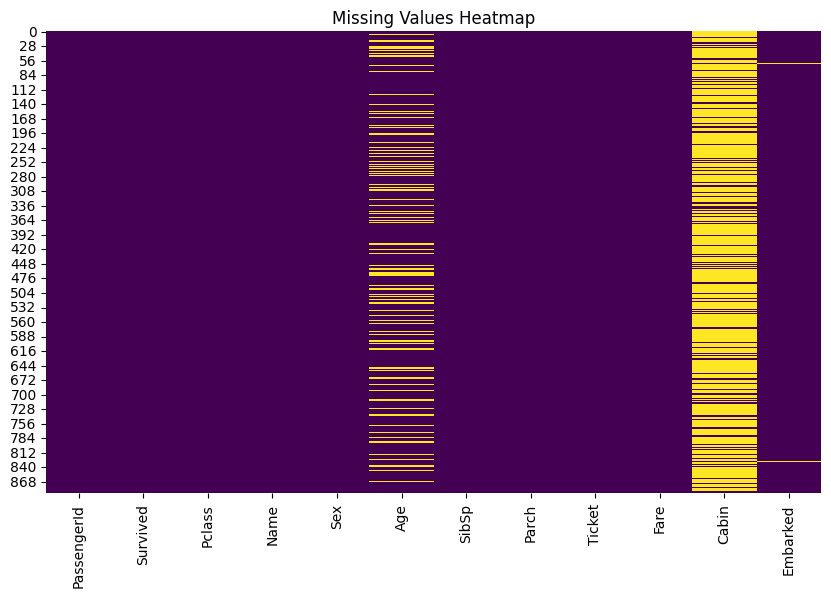

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Bar Plot of Missing Percentages

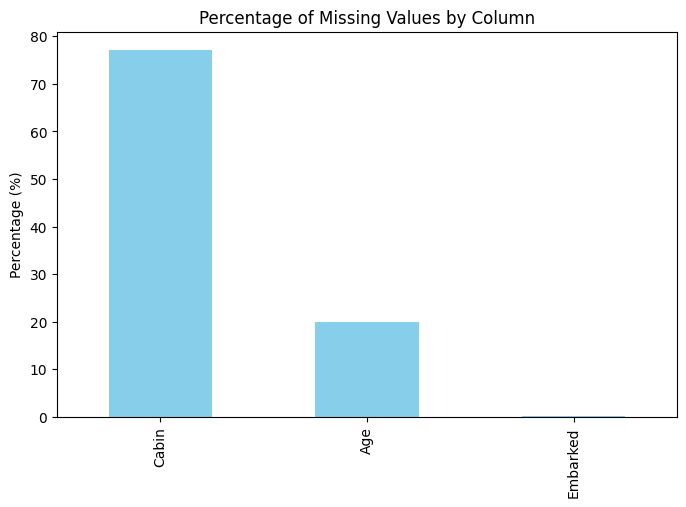

In [13]:
# Filter columns with missing values
missing_pct = missing_pct[missing_pct > 0]

# Plot
plt.figure(figsize=(8, 5))
missing_pct.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.show()

## Handle Missing Values
- Embarked: Fill with mode (most frequent value, likely 'S') due to only 0.22% missing.
- Age: Fill with median to handle 19.87% missing, as it’s robust to outliers.
- Cabin: Drop due to 77.10% missing, as imputation would introduce significant bias. Cabin is often correlated with Pclass or Fare, which capture similar information (socioeconomic status/deck location).

In [14]:
# Fill missing 'Embarked' with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fill missing 'Age' with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop 'Cabin' column
df.drop('Cabin', axis=1, inplace=True)

/tmp/ipykernel_36/2764951993.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_36/2764951993.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [15]:
# Verify no missing values remain
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [17]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Embarked         3
dtype: int64

## Encode Categorical Features


- Sex: 2 categories (male, female) → Use LabelEncoder (binary).
- Embarked: 3 categories (S, C, Q) → Use OneHotEncoder (non-ordinal).
- Pclass: 3 categories (1, 2, 3) → Treat as ordinal (numerical) or one-hot encode if non-ordinal.
- Name, Ticket: High cardinality (many unique values), drop unless engineered.
- PassengerId: Unique identifier, drop.

## Count Plot for Sex

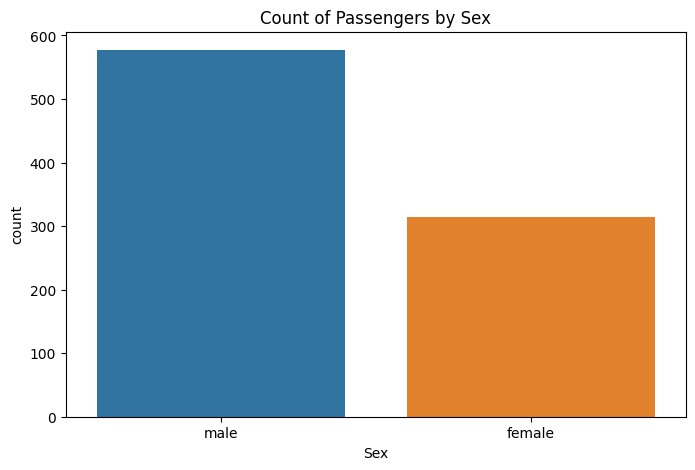

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', data=df)
plt.title('Count of Passengers by Sex')
plt.show()

## Count Plot for Embarked

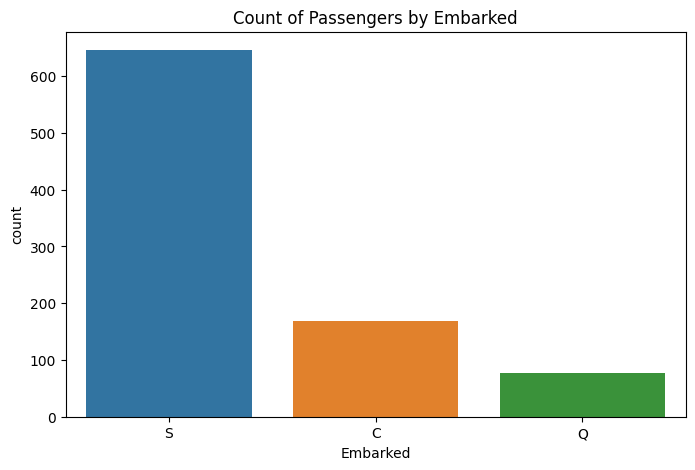

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', data=df)
plt.title('Count of Passengers by Embarked')
plt.show()

## Survival Rate by Embarked

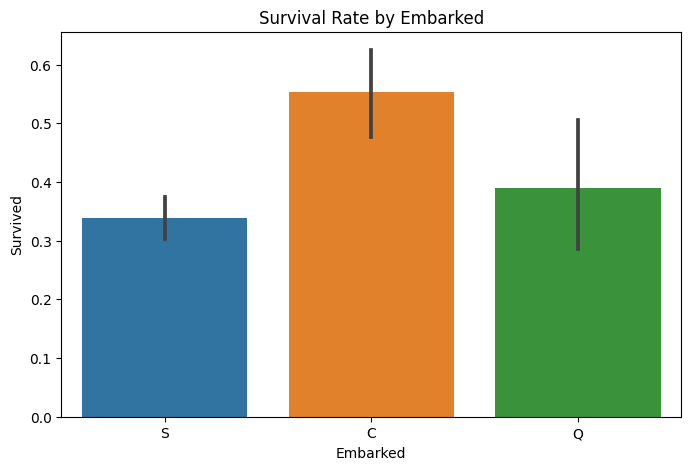

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarked')
plt.show()

## Survival Rate by Pclass

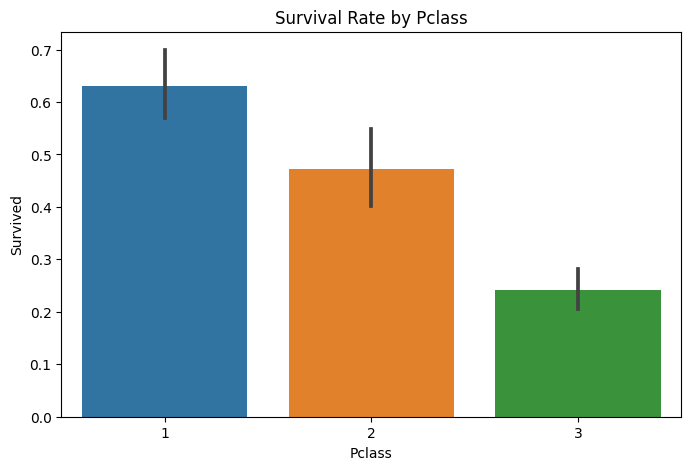

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Pclass')
plt.show()

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Label encode 'Sex'
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# One-hot encode 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

#  One-hot encode 'Pclass' if treating as non-ordinal
df = pd.get_dummies(df, columns=['Pclass'], prefix='Pclass')

# Display updated dataframe
print(df.head())

   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

   Sex   Age  SibSp  Parch            Ticket     Fare  Embarked_C  Embarked_Q  \
0    1  22.0      1      0         A/5 21171   7.2500       False       False   
1    0  38.0      1      0          PC 17599  71.2833        True       False   
2    0  26.0      0      0  STON/O2. 3101282   7.9250       False       False   
3    0  35.0      1      0            113803  53.1000       False       False   
4    1  35.0      0      0            373450   8.0500       False       False   

   Embarked_S  Pclass_1  Pclass_2  Pcl

## Scale Numerical Features

In [23]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

# Scale numerical features
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display scaled features
print(df[numerical_features].head())

        Age      Fare     SibSp     Parch
0 -0.565736 -0.502445  0.432793 -0.473674
1  0.663861  0.786845  0.432793 -0.473674
2 -0.258337 -0.488854 -0.474545 -0.473674
3  0.433312  0.420730  0.432793 -0.473674
4  0.433312 -0.486337 -0.474545 -0.473674


## Drop Unnecessary Columns
- Drop PassengerId, Name, Ticket

In [24]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
print(df.head())

   Survived  Sex       Age     SibSp     Parch      Fare  Embarked_C  \
0         0    1 -0.565736  0.432793 -0.473674 -0.502445       False   
1         1    0  0.663861  0.432793 -0.473674  0.786845        True   
2         1    0 -0.258337 -0.474545 -0.473674 -0.488854       False   
3         1    0  0.433312  0.432793 -0.473674  0.420730       False   
4         0    1  0.433312 -0.474545 -0.473674 -0.486337       False   

   Embarked_Q  Embarked_S  Pclass_1  Pclass_2  Pclass_3  
0       False        True     False     False      True  
1       False       False      True     False     False  
2       False        True     False     False      True  
3       False        True      True     False     False  
4       False        True     False     False      True  


In [25]:
# Summary Statistics:
print(df.describe())

         Survived         Sex           Age         SibSp         Parch  \
count  891.000000  891.000000  8.910000e+02  8.910000e+02  8.910000e+02   
mean     0.383838    0.647587  2.232906e-16  3.588600e-17  5.681949e-17   
std      0.486592    0.477990  1.000562e+00  1.000562e+00  1.000562e+00   
min      0.000000    0.000000 -2.224156e+00 -4.745452e-01 -4.736736e-01   
25%      0.000000    0.000000 -5.657365e-01 -4.745452e-01 -4.736736e-01   
50%      0.000000    1.000000 -1.046374e-01 -4.745452e-01 -4.736736e-01   
75%      1.000000    1.000000  4.333115e-01  4.327934e-01 -4.736736e-01   
max      1.000000    1.000000  3.891554e+00  6.784163e+00  6.974147e+00   

               Fare  
count  8.910000e+02  
mean  -1.993666e-18  
std    1.000562e+00  
min   -6.484217e-01  
25%   -4.891482e-01  
50%   -3.573909e-01  
75%   -2.424635e-02  
max    9.667167e+00  


## Correlation Heatmap:

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


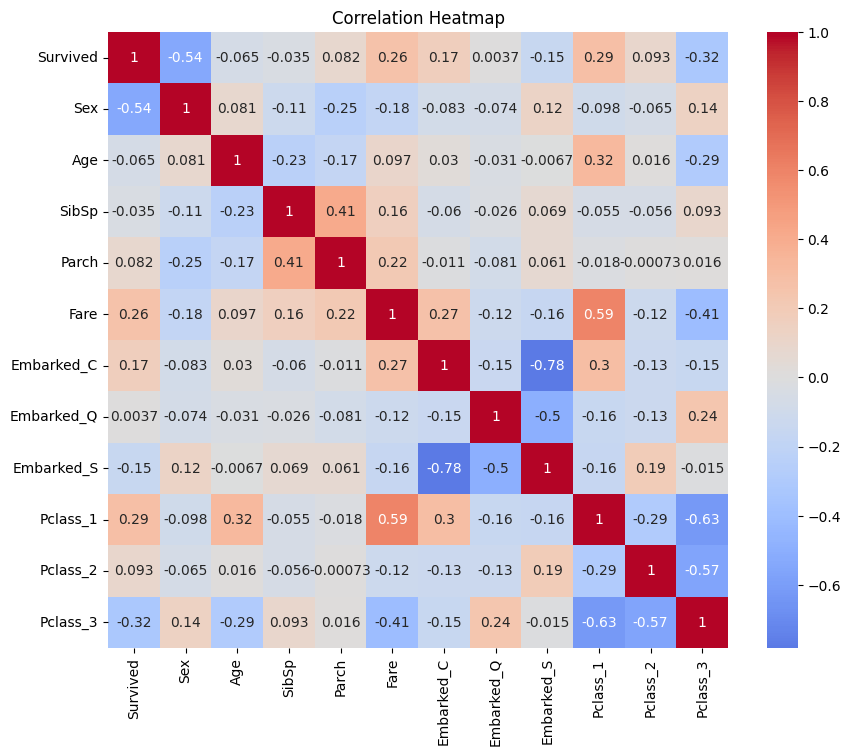

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [27]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,1,-0.565736,0.432793,-0.473674,-0.502445,False,False,True,False,False,True
1,1,0,0.663861,0.432793,-0.473674,0.786845,True,False,False,True,False,False
2,1,0,-0.258337,-0.474545,-0.473674,-0.488854,False,False,True,False,False,True
3,1,0,0.433312,0.432793,-0.473674,0.420730,False,False,True,True,False,False
4,0,1,0.433312,-0.474545,-0.473674,-0.486337,False,False,True,False,False,True


In [29]:
df = df.astype(int)  # converts True/False to 0/1 for all boolean columns
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,1,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,0,0,1,0,0,1,0,0
2,1,0,0,0,0,0,0,0,1,0,0,1
3,1,0,0,0,0,0,0,0,1,1,0,0
4,0,1,0,0,0,0,0,0,1,0,0,1


## Define Features & Target

In [30]:
X = df.drop("Survived", axis=1)  # independent variables
y = df["Survived"]               # target


In [31]:
X

,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,1,0,0,0,0,0,0,1,0,0,1
1,0,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,0,1
3,0,0,0,0,0,0,0,1,1,0,0
4,1,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,1,0,0,0,0,0,0,1,0,1,0
887,0,0,0,0,0,0,0,1,1,0,0
888,0,0,0,2,0,0,0,1,0,0,1
889,1,0,0,0,0,1,0,0,1,0,0


In [32]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

## Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Train Decision Tree

In [34]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)  # limit depth to avoid overfitting
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.7877094972067039


## Train Logistic Regression

In [35]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)


Logistic Regression Accuracy: 0.8156424581005587


## Compare Results

Decision Tree Accuracy: 0.7877094972067039
Logistic Regression Accuracy: 0.8156424581005587


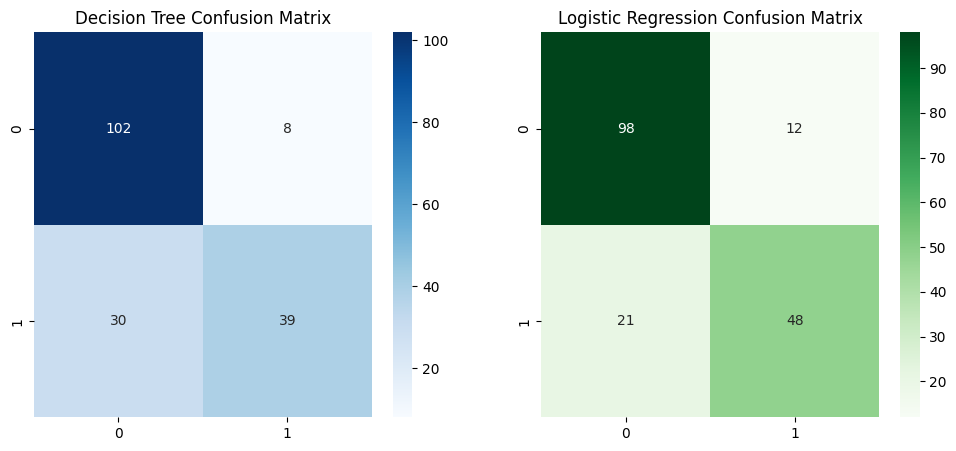

In [36]:
print("Decision Tree Accuracy:", dt_acc)
print("Logistic Regression Accuracy:", lr_acc)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")

plt.show()


## Classification Reports

In [38]:
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))


Decision Tree Report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84       110
           1       0.83      0.57      0.67        69

    accuracy                           0.79       179
   macro avg       0.80      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



### Summary:
- Both Decision Tree and Logistic Regression models were trained on the cleaned Titanic dataset. Logistic Regression achieved higher accuracy (81.6%) compared to Decision Tree (78.8%), with better balance between precision and recall. The Decision Tree performed well at identifying non-survivors but struggled to capture survivors (lower recall). Logistic Regression generalized better, making it the stronger model for this dataset since survival is largely influenced by linear factors such as gender, passenger class, and fare.